In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.formula.api import ols

# Ways of creating a dataframe:
## 1 - A dictionary of list of column values
Here `key` - column name & `val` - list of values for that column

In [2]:
# a dictionary of column : column_values
datadf1 = {"Name": ["Alice", "Bob" , "Charlie","Mike"],
        "Age": [26, 27,29,30],
        "City": ["New York" , "London" , "Paris","Los Angeles"],
        "join_date":["2025-10-01", "2024-09-23" , "2025-06-10" , "2025-01-10"]}

# Loading as a dataframe
df1 = pd.DataFrame(datadf1)

# Converting join_date column to datetime format
df1["join_date"] = pd.to_datetime(df1["join_date"])

print(df1.dtypes)
print(df1)

Name                    str
Age                   int64
City                    str
join_date    datetime64[us]
dtype: object
      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   27       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [3]:
# Extracting only specific part of dates
df1["join_date"].dt.month_name()

0      October
1    September
2         June
3      January
Name: join_date, dtype: str

## Filtering rows / columns using `loc` & `iloc`

In [4]:
# Filtering based on iloc - works similar to lists indexing
df1.iloc[1, 1] = 28
print(df1)

      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   28       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [5]:
# Creating a copy of the dataset
df2 = df1.copy()
df2.set_index("Name", inplace=True)

In [6]:
# filtering using loc - used for named indexes
df2.loc["Bob":"Mike",['Age','join_date']]

,Age,join_date
Name,,
Bob,28,2024-09-23
Charlie,29,2025-06-10
Mike,30,2025-01-10


# Probability revision

In [7]:
df = pd.read_csv('../statistics_in_python/stats_datasets/weightsheights.csv', usecols=["Height in cm" , "Weight in kg"]).round(2)
df.columns = df.columns.str.replace(' ', '_')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Height_in_cm  25000 non-null  float64
 1   Weight_in_kg  25000 non-null  float64
dtypes: float64(2)
memory usage: 390.8 KB


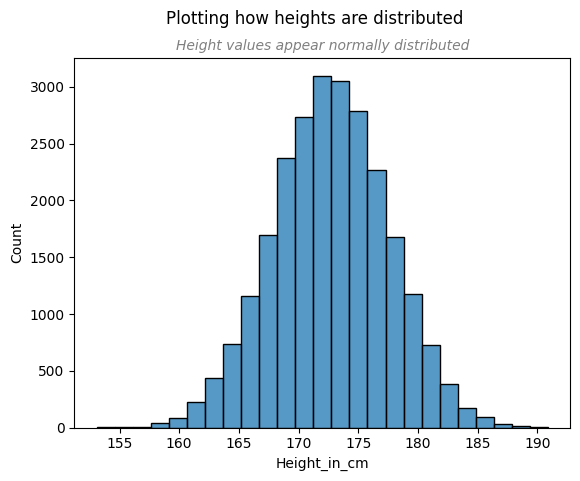

In [8]:
# Finding kind of distribution for the height values 
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()

> Thus its observed that majority of heights are between 168-176 cm, quantiles will give better idea

In [9]:
the_quantiles = [0.25, 0.5 , 0.75, 1]

for each in the_quantiles: 
    print(f"Heights in {each}-ile : {np.quantile(df["Height_in_cm"],each)}")    


Heights in 0.25-ile : 169.43
Heights in 0.5-ile : 172.71
Heights in 0.75-ile : 175.95
Heights in 1-ile : 190.89


Text(0.5, 1.0, 'Overview of statistics using boxplot')

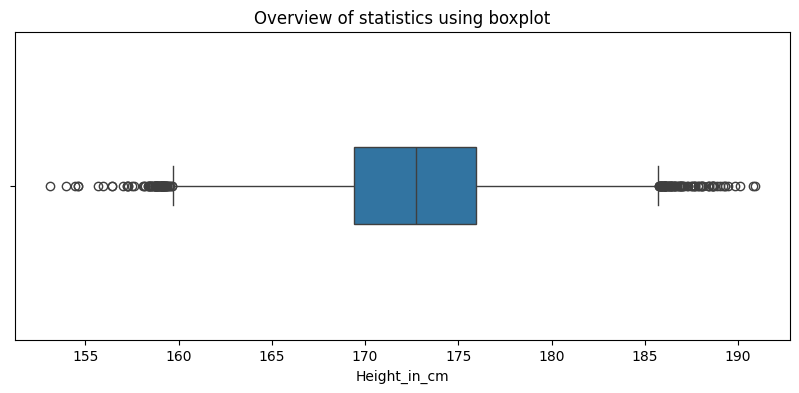

In [10]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Height_in_cm", width=0.25)
plt.title("Overview of statistics using boxplot")

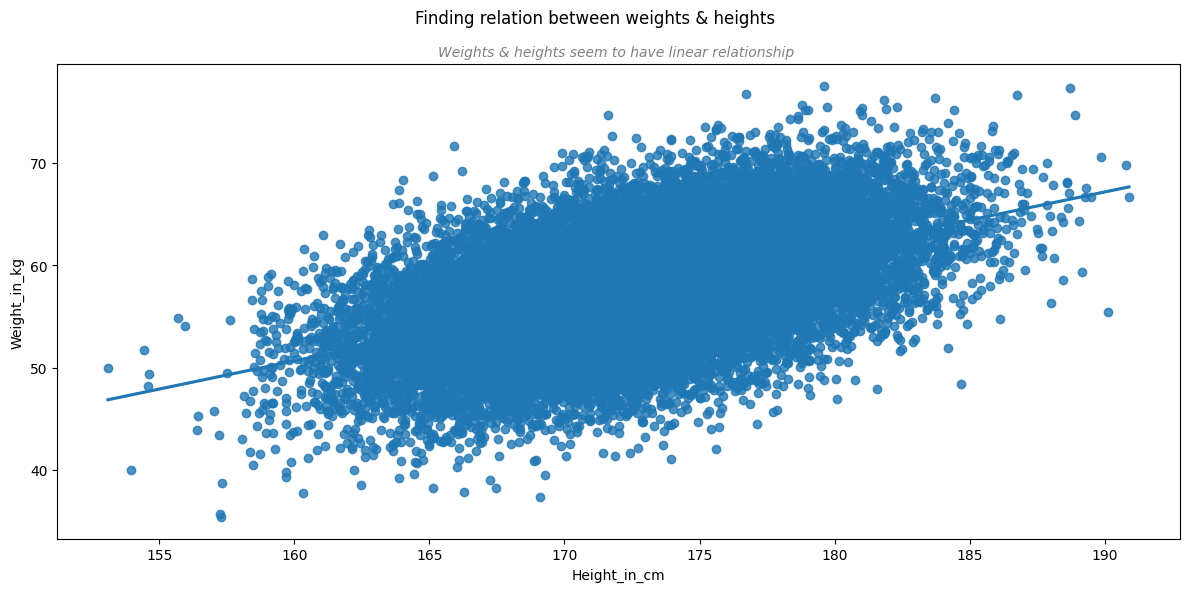

In [11]:
# Finding relation between weights & heights
plt.figure(figsize=(12,6))
sns.regplot(data=df , x= 'Height_in_cm' , y='Weight_in_kg', ci=None)
plt.suptitle('Finding relation between weights & heights')
plt.title("Weights & heights seem to have linear relationship " , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.tight_layout()
plt.show()


## Determining the fit  

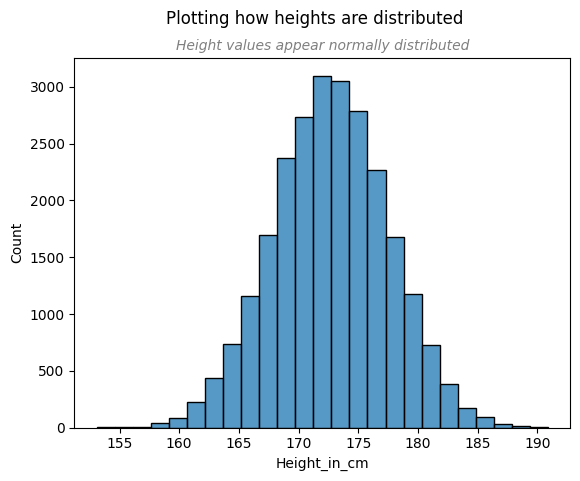

In [12]:
# Finding kind of distribution for the height values 
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Determining the fit  

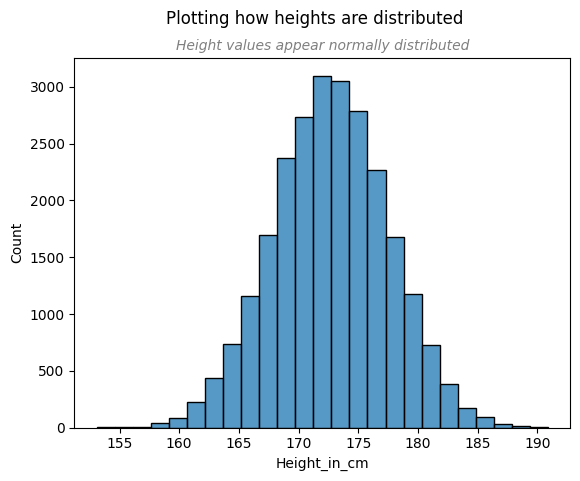

In [ ]:
# Finding kind of distribution for the height values 
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Finding likelihood
**Q: What is the probability% that a person's height from the dataset < 172cm?**

In [14]:
height_mean = df.describe().loc["mean", "Height_in_cm"]
height_stdev  = df.describe().loc["std", "Height_in_cm"]

In [15]:
norm.cdf(172, height_mean , height_stdev)

np.float64(0.44218866026199904)

>So there's a 44% chance that a person's height, selected randomly from the dataset, is less than 172cm .


**Q: What is the probability% that a person's height from the dataset > 178cm?**

In [16]:
1 - norm.cdf(178, height_mean , height_stdev)

np.float64(0.1363767033562957)

>So there's a 13.6% chance that a person's height, selected randomly from the dataset, is more than than 178cm .

**Q: What is the probability% that a person's height from the dataset is exactly 178cm?**

In [17]:
norm.pdf(178, height_mean , height_stdev)

np.float64(0.045263032907543306)

>So there's a 4.5% chance that a person's height, selected randomly from the dataset, is exactly 178cm .

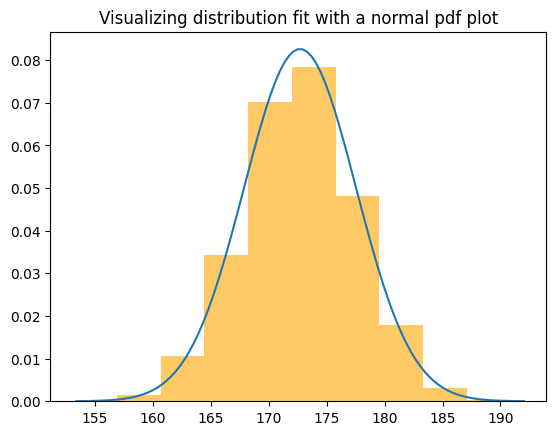

In [41]:
import scipy.stats

mu=height_mean
sigma=height_stdev

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)
plt.hist(df["Height_in_cm"] , density=True, alpha=0.6, color='orange', label='Actual Data')
plt.title("Visualizing distribution fit with a normal pdf plot")
plt.plot(x,y)
plt.show()

If you were to run that same code with $n=500$:

- At $n=50$: Your histogram might look a bit "jagged," and the PDF curve is relatively wide.
- At $n=500$: The histogram bars would align almost perfectly with the PDF curve, and the entire structure would be much thinner and taller.

# Linear Regression
For the given `weightsheights.csv` dataset,consider:

- `height_in_cm` is explanatory (independent) variable

- `weight_in_kg` is response (independent) variable

In [43]:
model = ols("Weight_in_kg ~ Height_in_cm", data=df).fit()
model.params

Intercept      -37.454069
Height_in_cm     0.550637
dtype: float64

### The linear equation formed is : 

Weight is calculated as: $Weight = (0.55\times Height) - 37.45$

>This means , for every 1cm increase in height, there's a 0.55X increase in the weight.

In [47]:
model.predict({"Height_in_cm":170})

0    56.154285
dtype: float64

# Revision of Sampling

In [20]:
# np.random.seed(2022)
normaldf = pd.DataFrame({"val":np.round(np.random.normal(10,3.0,size=5000),2)})

In [21]:
# Takinga Sample containing 50 values
norm_sampledf = normaldf.sample(n=100)
norm_sampledf

,val
4675,12.13
2475,8.88
4039,5.81
4903,11.48
3461,9.33
...,...
907,12.39
3965,6.35
301,12.35
875,3.44


Mean of the sample: val    10.0802
dtype: float64


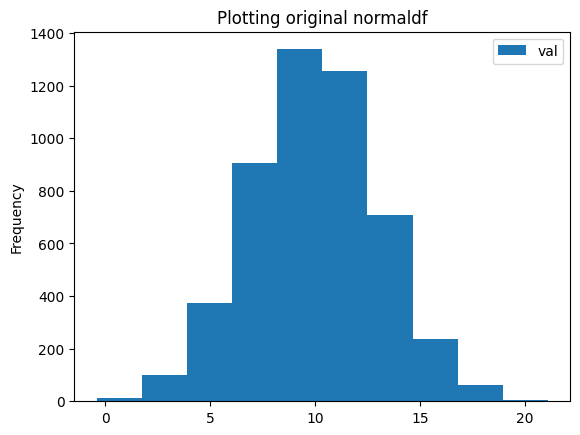

In [22]:
norm_sampledf_mean = norm_sampledf.mean()
print(f"Mean of the sample: {norm_sampledf_mean}")
normaldf.plot.hist()
plt.title("Plotting original normaldf")
plt.show()

In [23]:
# taking mean of 50 such samples -- using for loop
# intiating as an empty list
mean_of_50samples = []
# using a for loop to generate the means
for i in range(1000):
    mean_of_50samples.append(np.mean(norm_sampledf.sample(n=50)))

In [24]:
# Now taking a mean of means of these samples
np.mean(mean_of_50samples)

np.float64(10.0783096)

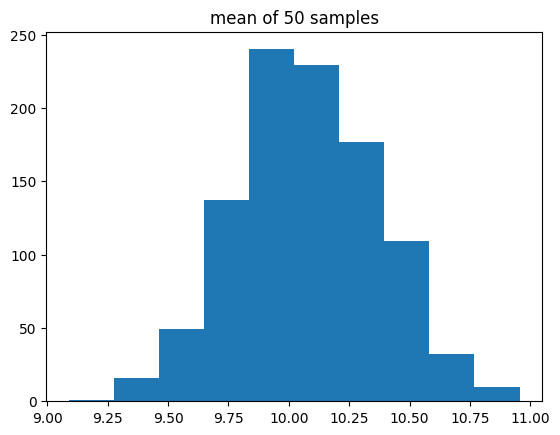

In [25]:
plt.title("mean of 50 samples")
plt.hist(mean_of_50samples)
plt.show()

Proof that , as sampling size increases, the mean of all sampling mean approaches to the true population mean. (Law of large numbers) 